# Pronóstico de demanda de taxis en aeropuertos

## Contexto de negocio

Sweet Lift Taxi necesita anticipar la demanda de viajes en aeropuertos para mejorar la disponibilidad de conductores durante las horas de mayor actividad. Una estimación oportuna permite alinear la capacidad operativa con los cambios horarios de la demanda, reducir tiempos de espera y respaldar una asignación más eficiente de recursos.

## Objetivo analítico

Desarrollar y evaluar modelos de series temporales capaces de predecir el número de pedidos de taxi para la siguiente hora a partir del comportamiento histórico de la demanda.

## Criterio de desempeño

La solución se evaluará mediante la raíz del error cuadrático medio (RMSE). El resultado en el conjunto de prueba debe ser igual o inferior a 48 pedidos por hora.

## Datos disponibles

La información contiene registros históricos con intervalos de diez minutos. La variable `num_orders` representa el número de pedidos y `datetime` identifica el momento de cada observación.

## Preparación y validación de datos

Se configura el entorno analítico y se incorporan las herramientas necesarias para el tratamiento de series temporales, la construcción de variables, el entrenamiento de modelos y la evaluación de resultados.

In [13]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

plt.style.use('default')
sns.set_theme()

RANDOM_STATE = 12345

### Carga y revisión inicial

Los registros se cargan utilizando la fecha y hora como índice. A continuación, se valida el orden cronológico, la estructura del conjunto de datos, la presencia de valores ausentes y la distribución de la demanda.

In [14]:
data = pd.read_csv('../../1data_local/data_airport_taxi_demand_forecasting/taxi.csv', parse_dates=['datetime'], index_col='datetime')

if not data.index.is_monotonic_increasing:
    print("El índice NO está ordenado. Procediendo a ordenarlo...")
    data = data.sort_index()
else:
    print("Índice ya ordenado correctamente.")

display(data.head())
print("\nShape del dataset:", data.shape)

print("\nInformación del DataFrame:")
display(data.info())

print("\nNulos por columna:")
display(data.isna().sum())

print("\nDuplicados:", data.duplicated().sum())

print("\nDescripción estadística:")
display(data.describe())

Índice ya ordenado correctamente.


,num_orders
datetime,
2018-03-01 00:00:00,9
2018-03-01 00:10:00,14
2018-03-01 00:20:00,28
2018-03-01 00:30:00,20
2018-03-01 00:40:00,32



Shape del dataset: (26496, 1)

Información del DataFrame:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB


None


Nulos por columna:


num_orders    0
dtype: int64


Duplicados: 26415

Descripción estadística:


,num_orders
count,26496.000000
mean,14.070463
std,9.211330
min,0.000000
25%,8.000000
50%,13.000000
75%,19.000000
max,119.000000


### Interpretación de la revisión inicial

El conjunto contiene 26,496 observaciones ordenadas cronológicamente, sin valores ausentes y con `num_orders` en formato entero.

El resultado de `data.duplicated()` indica que existen valores repetidos en la columna `num_orders`; no demuestra que haya marcas de tiempo duplicadas, ya que el índice temporal no se considera en esta comprobación. En una serie de demanda es normal que distintas horas registren la misma cantidad de pedidos, por lo que estos valores repetidos no deben eliminarse. La consolidación horaria se realizará mediante remuestreo, sin tratar dichas coincidencias como errores de calidad.

### Consolidación de la demanda por hora

Los registros de diez minutos se agrupan en intervalos horarios mediante la suma de pedidos. Esta frecuencia corresponde al horizonte operativo que se desea anticipar.

Shape original (10 minutos): (26496, 1)
Shape remuestreado (1H): (4416, 1)

Vista inicial de la serie remuestreada:


,num_orders
datetime,
2018-03-01 00:00:00,124
2018-03-01 01:00:00,85
2018-03-01 02:00:00,71
2018-03-01 03:00:00,66
2018-03-01 04:00:00,43



Vista final de la serie remuestreada:


,num_orders
datetime,
2018-08-31 19:00:00,136
2018-08-31 20:00:00,154
2018-08-31 21:00:00,159
2018-08-31 22:00:00,223
2018-08-31 23:00:00,205



Información del DataFrame remuestreado:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4416 entries, 2018-03-01 00:00:00 to 2018-08-31 23:00:00
Freq: h
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  4416 non-null   int64
dtypes: int64(1)
memory usage: 69.0 KB


None


Nulos después del remuestreo:


num_orders    0
dtype: int64


Duplicados después del remuestreo: 4165

Descripción estadística de la serie remuestreada:


,num_orders
count,4416.000000
mean,84.422781
std,45.023853
min,0.000000
25%,54.000000
50%,78.000000
75%,107.000000
max,462.000000


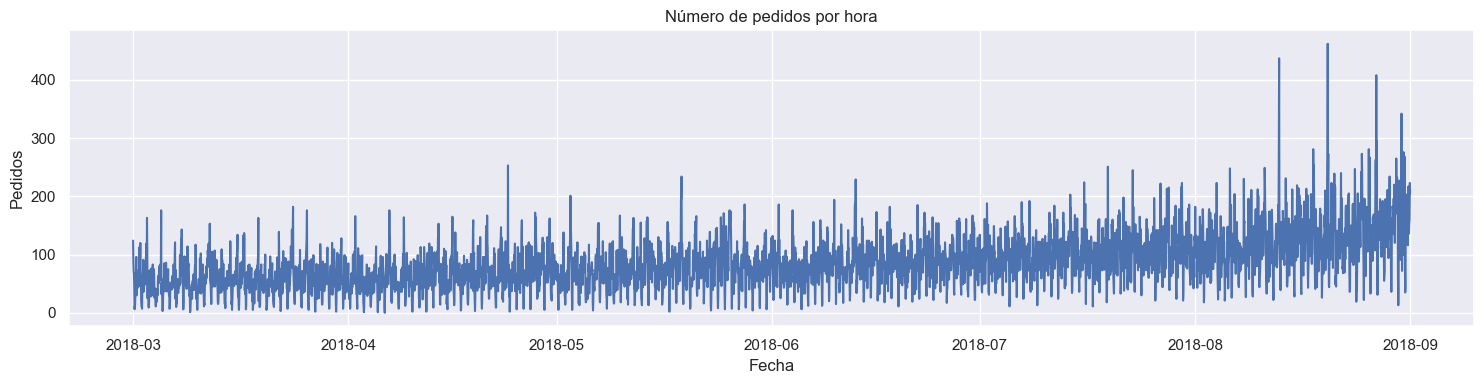

In [15]:
data_hourly = data.resample('1H').sum()

print("Shape original (10 minutos):", data.shape)
print("Shape remuestreado (1H):", data_hourly.shape)

print("\nVista inicial de la serie remuestreada:")
display(data_hourly.head())
print("\nVista final de la serie remuestreada:")
display(data_hourly.tail())

print("\nInformación del DataFrame remuestreado:")
display(data_hourly.info())

print("\nNulos después del remuestreo:")
display(data_hourly.isna().sum())

print("\nDuplicados después del remuestreo:", data_hourly.duplicated().sum())

print("\nDescripción estadística de la serie remuestreada:")
display(data_hourly.describe())

plt.figure(figsize=(15, 4))
plt.plot(data_hourly.index, data_hourly['num_orders'])
plt.title('Número de pedidos por hora')
plt.xlabel('Fecha')
plt.ylabel('Pedidos')
plt.tight_layout()
plt.show()

### Resultado del remuestreo

La serie pasa de 26,496 registros de diez minutos a 4,416 observaciones horarias. No se generan valores ausentes y la frecuencia queda establecida correctamente.

La demanda promedio es de aproximadamente 84 pedidos por hora, con una desviación estándar cercana a 45 y un máximo de 462. La evolución temporal muestra mayor actividad hacia julio y agosto, además de variaciones recurrentes que justifican un análisis de tendencia y estacionalidad.

## Análisis temporal

### Tendencia y estacionalidad diaria

La serie horaria se descompone con un período de 24 horas para separar tendencia, estacionalidad diaria y variación residual.

<Figure size 1400x1000 with 0 Axes>

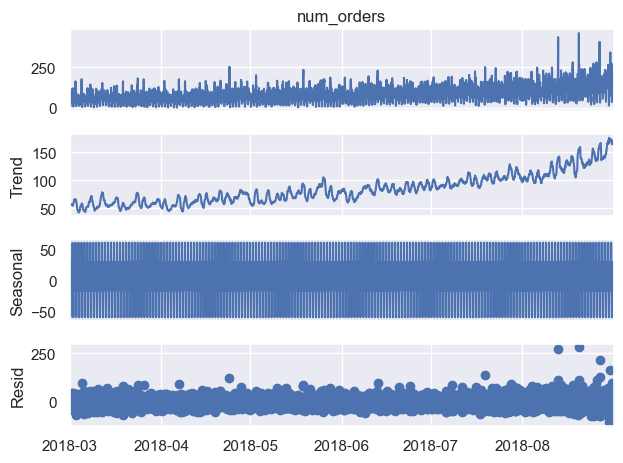

In [16]:
decomposition = seasonal_decompose(data_hourly['num_orders'], model='additive', period=24)

plt.figure(figsize=(14, 10))
decomposition.plot()
plt.tight_layout()
plt.show()

### Hallazgos del comportamiento temporal

- **Tendencia:** la demanda presenta un crecimiento progresivo entre marzo y agosto.
- **Estacionalidad diaria:** se observan ciclos que se repiten cada 24 horas, compatibles con horas de mayor y menor actividad.
- **Variación residual:** existen picos aislados, especialmente hacia agosto, que pueden corresponder a eventos puntuales de alta demanda.

Estos patrones respaldan la incorporación de variables de calendario, rezagos horarios y promedios móviles para representar la dinámica reciente de la demanda.

## Ingeniería de variables

Se generan variables de hora, día de la semana y mes, junto con 24 rezagos horarios y un promedio móvil de 24 horas. El promedio móvil se desplaza una hora para asegurar que cada predicción utilice únicamente información disponible hasta el momento anterior.

In [17]:
def make_features(data, max_lag, rolling_mean_size):

    data = data.copy()

    data['hour'] = data.index.hour
    data['dayofweek'] = data.index.dayofweek
    data['month'] = data.index.month

    for lag in range(1, max_lag + 1):
        data[f'lag_{lag}'] = data['num_orders'].shift(lag)

    data['rolling_mean'] = (
        data['num_orders']
        .shift()
        .rolling(window=rolling_mean_size)
        .mean()
    )

    return data

MAX_LAG = 24
ROLLING_WINDOW = 24

data_with_features = make_features(data_hourly, MAX_LAG, ROLLING_WINDOW)

print("Shape con características:", data_with_features.shape)
display(data_with_features.head())
print("\nNulos después de crear características:")
display(data_with_features.isna().sum().head(15))

Shape con características: (4416, 29)


,num_orders,hour,dayofweek,month,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,...,lag_16,lag_17,lag_18,lag_19,lag_20,lag_21,lag_22,lag_23,lag_24,rolling_mean
datetime,,,,,,,,,,,,,,,,,,,,,
2018-03-01 00:00:00,124,0,3,3,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 01:00:00,85,1,3,3,124.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 02:00:00,71,2,3,3,85.0,124.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 03:00:00,66,3,3,3,71.0,85.0,124.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2018-03-01 04:00:00,43,4,3,3,66.0,71.0,85.0,124.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Nulos después de crear características:


num_orders     0
hour           0
dayofweek      0
month          0
lag_1          1
lag_2          2
lag_3          3
lag_4          4
lag_5          5
lag_6          6
lag_7          7
lag_8          8
lag_9          9
lag_10        10
lag_11        11
dtype: int64

### Resultado de la transformación

La matriz analítica queda conformada por 29 columnas. Los valores ausentes de las primeras observaciones son una consecuencia esperada de los rezagos y del promedio móvil; se retirarán antes del entrenamiento sin alterar el período reservado para la evaluación final.

## Entrenamiento y evaluación

### División temporal de los datos

El 90 % inicial de las observaciones se utiliza para entrenamiento y el 10 % más reciente para prueba. Esta separación conserva el orden cronológico y reproduce un escenario en el que se pronostican períodos posteriores a partir de información histórica.

In [18]:
test_size = int(len(data_with_features) * 0.10)

train = data_with_features.iloc[:-test_size].copy()
test = data_with_features.iloc[-test_size:].copy()

print("Tamaño train antes de dropna:", train.shape)
print("Tamaño test              :", test.shape)

train = train.dropna()

print("\nTamaño train después de dropna:", train.shape)
print("Tamaño test (sin cambios):     ", test.shape)

features_train = train.drop('num_orders', axis=1)
target_train = train['num_orders']

features_test = test.drop('num_orders', axis=1)
target_test = test['num_orders']

Tamaño train antes de dropna: (3975, 29)
Tamaño test              : (441, 29)

Tamaño train después de dropna: (3951, 29)
Tamaño test (sin cambios):      (441, 29)


El conjunto de entrenamiento contiene 3,975 observaciones antes de retirar los valores ausentes generados por los rezagos y 3,951 después de la depuración. El conjunto de prueba conserva 441 observaciones.

### Entrenamiento de modelos

Se comparan tres enfoques: Regresión Lineal, Árbol de Decisión y Random Forest. La métrica RMSE permite cuantificar el error promedio de predicción en las mismas unidades que la demanda horaria.

In [19]:
def rmse(true, pred):
    return root_mean_squared_error(true, pred)

results_train = {}

lr_model = LinearRegression()
lr_model.fit(features_train, target_train)
train_pred_lr = lr_model.predict(features_train)
results_train['Linear Regression'] = rmse(target_train, train_pred_lr)

dt_model = DecisionTreeRegressor(random_state=RANDOM_STATE, max_depth=10)
dt_model.fit(features_train, target_train)
train_pred_dt = dt_model.predict(features_train)
results_train['Decision Tree'] = rmse(target_train, train_pred_dt)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_model.fit(features_train, target_train)
train_pred_rf = rf_model.predict(features_train)
results_train['Random Forest'] = rmse(target_train, train_pred_rf)

results_train

{'Linear Regression': 25.743002541276727,
 'Decision Tree': 15.571150857552398,
 'Random Forest': 14.218487759844471}

### Desempeño durante el entrenamiento

| Modelo | RMSE de entrenamiento |
|---|---:|
| Regresión Lineal | 25.74 |
| Árbol de Decisión | 15.57 |
| Random Forest | **14.22** |

Los modelos basados en árboles capturan con mayor precisión las relaciones no lineales presentes en las variables temporales. Random Forest registra el menor error dentro de la muestra de entrenamiento.

### Evaluación sobre el período de prueba

Los modelos entrenados se aplican al 10 % final de la serie para medir su capacidad de generalización sobre observaciones posteriores.

In [20]:
results_test = {}

test_pred_lr = lr_model.predict(features_test)
results_test['Linear Regression'] = rmse(target_test, test_pred_lr)

test_pred_dt = dt_model.predict(features_test)
results_test['Decision Tree'] = rmse(target_test, test_pred_dt)

test_pred_rf = rf_model.predict(features_test)
results_test['Random Forest'] = rmse(target_test, test_pred_rf)

results_test

{'Linear Regression': 45.73445299292907,
 'Decision Tree': 60.9523810024473,
 'Random Forest': 44.39836215944284}

### Comparación final

| Modelo | RMSE de entrenamiento | RMSE de prueba |
|---|---:|---:|
| Regresión Lineal | 25.74 | 45.73 |
| Árbol de Decisión | 15.57 | 60.95 |
| Random Forest | 14.22 | **44.40** |

Random Forest obtiene el mejor desempeño en el período de prueba con un RMSE de 44.40 pedidos por hora, resultado inferior al límite establecido de 48. Esta evaluación demuestra capacidad predictiva dentro del período analizado, pero una sola división temporal no permite afirmar que el modelo esté listo para su implementación. El Árbol de Decisión muestra una diferencia considerable entre entrenamiento y prueba, señal de una menor capacidad de generalización.

## Conclusiones ejecutivas

- Random Forest ofrece el mejor equilibrio entre ajuste y desempeño fuera de la muestra, con un RMSE final de 44.40 pedidos por hora.
- La hora, el día de la semana, los rezagos y el promedio móvil permiten representar patrones relevantes para anticipar la demanda de la siguiente hora.
- Los resultados aportan una base analítica para evaluar decisiones de corto plazo relacionadas con disponibilidad de conductores y cobertura durante períodos de alta actividad.
- Antes de utilizar el modelo en un entorno operativo, es necesario validarlo en múltiples períodos temporales, compararlo con una referencia simple, monitorear periódicamente el error y definir un proceso de actualización ante cambios en el comportamiento de la demanda.